## DDIM 기초 구현

### 구현해야될 항목
- DDIM sampling 코드
  - 기본 모델은 ddpm의 가중치를 이용할 예정

### 결과
- Sampling 20

  
  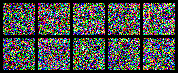
  
- Sampling 50

  
  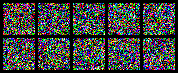

  
- Sampling 500

  
  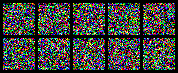
  - 수가 많아질수록 결과가 많이 안좋다
    


### 라이브러리

In [3]:
from tqdm import tqdm
import numpy as np

# torch
import torch
import torch.nn.functional as F

# dataset
from torchvision.datasets import CIFAR10
from torchvision import transforms
import torchvision.utils as vutils

# visualization
import cv2
import matplotlib.pyplot as plt
import imageio
import ddim_model
# check cuda
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    torch.device("cpu")
print(" Device: ", device)
# !pip install opencv-python
# !pip install imageio

 Device:  cuda:0


### 기본 계수 코드
- DDPM에서 사용했던 코드와 같음

In [4]:
# time t
T = 1000 
# beta: linear하게 증가
betas = torch.linspace(1e-4, 0.02, T).to(device) 
# alpha는 beta의 변형이므로
alphas = 1 - betas
# alpha bar는 alhpa의 누적 합 -> torch의 cumprod 함수
alphas_bar = torch.cumprod(alphas, dim = 0, ).to(device)
# alpha bar 의 t-1도 sampling 과정에서 필요하다. 
# 맨 처음에 alpha가 하나도 없었다는 뜻으로 맨 앞에 1을 추가.
alphas_bar_prev = F.pad(alphas_bar[:-1], (1, 0), value = 1)
#training에 필요한 변수
sqrt_alphas_bar = torch.sqrt(alphas_bar).to(device)
sqrt_one_minus_alphas_bar = torch.sqrt(1. - alphas_bar).to(device)

### DDIM 샘플링 코드
   
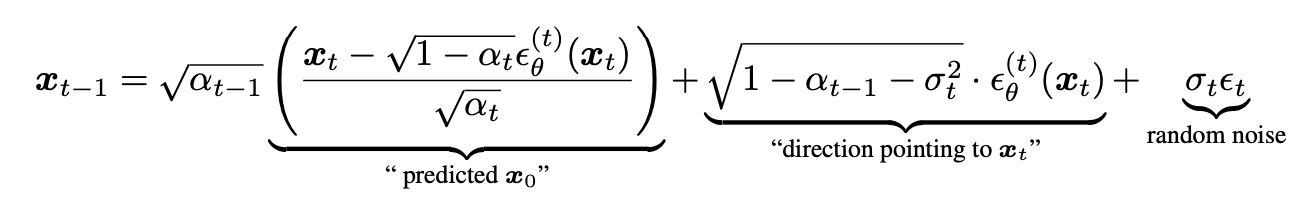

- 논문과 같게 $\sigma_t = 0$ 으로 설계 함
- $\bar\alpha_t = \alpha_t$
- ddpm과 다르게 $x_\text{t-1}$의 $\text{t-1}$은 step size에 따라 다르다

In [8]:
def ddim_denoise_step(x_t, eps, time_curr, time_next):
    # ddim sampling 구현
    term1 = torch.sqrt(alphas_bar_prev[time_next]) / sqrt_alphas_bar[time_curr] * (x_t - sqrt_one_minus_alphas_bar[time_curr] * eps)
    term2 = torch.sqrt(1 - alphas_bar_prev[time_next]) * eps
    x_t = term1 + term2  # 예측된 x0에 방향성 노이즈를 더한 값을 반환
    return x_t
    
def sample(model, x_T, n = 20): # x_T: noisy data
    x_t = x_T
    samples = []
    time_steps = np.linspace(T-1, 0, n, dtype=int) # n개의 개수로 time step 만들기
    for idx in range(len(time_steps)-1):
        time_curr, time_next = time_steps[idx]  , time_steps[idx+1] 
        # 각 time_step를 batch size로 확장
        t = torch.full((x_T.shape[0], ), time_curr, dtype=torch.long, device=device)
        # 업데이트 과정
        eps = model(x_t, t) # 모델 예측
        # denoise step
        x_t = ddim_denoise_step(x_t, eps, time_curr, time_next)
        # sampling gif 만들기
        if idx % 10 == 0 or idx > len(time_steps)-7 :
            grid = vutils.make_grid(x_t, nrow=5, padding=3) # grid 만들기 (C, H, W)
            grid = grid.permute(1, 2, 0).clamp(0, 1).cpu().numpy() * 255 # grid: (H, W, C)
            grid = grid.astype(np.uint8)
            samples.append(grid)
        
    imageio.mimsave(f"../resources/sample/ddim-sampling-epoch-{n}.gif", samples, fps=20)
    # 마지막 결과 return 
    x_0 = x_t
    return x_0

## **Make model,optimizer, scheduler instance**

In [9]:
model = ddim_model.UNet(T=T, ch=128, ch_mult=[1, 2, 2, 1], attn=[1],
             num_res_blocks=2, dropout=0.1).to(device)
optim = torch.optim.Adam(model.parameters(), lr=2e-4)
#sched = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda=warmup_lr)

## **Sampling**

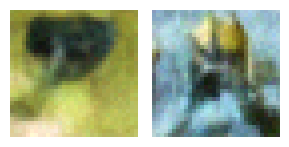

In [12]:
checkpoint_path = "../resources/weights/ddpm-1-model-epoch-200.pth"
# state_dict 로드
state_dict = torch.load(checkpoint_path, weights_only=True, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# 샘플링 수행
with torch.no_grad():
    # 샘플링 시작점 (가우시안 노이즈)
    x_T = torch.randn(10, 3, 32, 32).to(device)

    # 모델로부터 x_0 생성 
    x_0 = sample(model, x_T, n = 10)
    
    #    여기서는 B=10 개 중 2개만 확인 예시
    x_0 = x_0.permute(0, 2, 3, 1).clamp(0, 1).detach().cpu().numpy() * 255 #    x_0: (B, C, H, W) -> (B, H, W, C) 
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3, 3))  # 1행 2열
    for i in range(2):
        axes[i].imshow(x_0[i].astype(np.uint8))
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()